# KuaiRand Test-Period Summary Statistics

This notebook summarizes the KuaiRand-27K test-period logs from 2022-04-22 to 2022-05-08. I use two scopes throughout:

- `standard_only`: the two standard recommendation log files for 2022-04-22 to 2022-05-08.
- `standard_plus_random`: the two standard files plus `log_random_4_22_to_5_08_27k.csv`. This is the main "all rows" scope used for random-intervention diagnostics.

Key results from the executed notebook:

| Quantity | Result |
|---|---:|
| Standard-only rows | 185,981,809 |
| Standard plus random rows | 187,167,868 |
| Random rows | 1,186,059 |
| Random rows as share of all rows | 0.634% |
| User-timestamps in `standard_plus_random` | 32,111,619 |
| User-timestamps with a random row | 1,186,049, or 3.69% |
| Random rows in truly singleton timestamps | 35,639, or 3.00% of random rows |
| Median videos per user-timestamp | 6 |
| Singleton user-timestamps | 2,347,975, or 7.31% of moments |
| Singleton rows as share of all rows | 1.25% |

Main interpretation: the test-period log is mostly not one-video-at-a-time. It is dominated by multi-video timestamp moments, with a median of 6 videos at the same `(user_id, time_ms)`. The random-intervention rows are also mostly not singleton moments after joining back to the standard rows at the same timestamp: only about 3.00% of random rows are in truly singleton timestamps.

In [1]:
from pathlib import Path

import polars as pl

pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(60)

candidate_roots = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path('/Users/haozhangao/Desktop/RecSys Research'),
]

PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'KuaiRand-27K' / 'data').exists()
)
DATA_DIR = PROJECT_ROOT / 'KuaiRand-27K' / 'data'
ANALYSIS_DIR = PROJECT_ROOT / 'python_code_KuaiRand'
OUT_DIR = ANALYSIS_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

STANDARD_TEST_FILES = [
    DATA_DIR / 'log_standard_4_22_to_5_08_27k_part1.csv',
    DATA_DIR / 'log_standard_4_22_to_5_08_27k_part2.csv',
]
RANDOM_TEST_FILE = DATA_DIR / 'log_random_4_22_to_5_08_27k.csv'

for path in STANDARD_TEST_FILES + [RANDOM_TEST_FILE]:
    assert path.exists(), f'Missing file: {path}'

SCOPES = {
    'standard_only': STANDARD_TEST_FILES,
    'standard_plus_random': STANDARD_TEST_FILES + [RANDOM_TEST_FILE],
}

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Output dir:   {OUT_DIR}')

Project root: /Users/haozhangao/Desktop/RecSys Research
Data dir:     /Users/haozhangao/Desktop/RecSys Research/KuaiRand-27K/data
Output dir:   /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs


## Raw Preview

This section prints the first 20 rows and all released columns from the concatenated `standard_plus_random` test-period files. Because the standard files are read first, the preview begins with standard rows where `is_rand = 0`.

The raw log has 19 columns:

`user_id`, `video_id`, `date`, `hourmin`, `time_ms`, `is_click`, `is_like`, `is_follow`, `is_comment`, `is_forward`, `is_hate`, `long_view`, `play_time_ms`, `duration_ms`, `profile_stay_time`, `comment_stay_time`, `is_profile_enter`, `is_rand`, `tab`.

Important raw-data observation: many adjacent rows share the same `user_id` and `time_ms`, which is why the notebook later groups by `(user_id, time_ms)` to measure how many videos were recorded at each timestamp moment.

In [2]:
preview_df = (
    pl.scan_csv(
        [str(path) for path in SCOPES['standard_plus_random']],
        infer_schema_length=100,
    )
    .head(20)
    .collect()
)

print(f'Preview shape: {preview_df.shape}')
print('Columns:')
for idx, col in enumerate(preview_df.columns, start=1):
    print(f'{idx:02d}. {col}')

display(preview_df)

Preview shape: (20, 19)
Columns:
01. user_id
02. video_id
03. date
04. hourmin
05. time_ms
06. is_click
07. is_like
08. is_follow
09. is_comment
10. is_forward
11. is_hate
12. long_view
13. play_time_ms
14. duration_ms
15. profile_stay_time
16. comment_stay_time
17. is_profile_enter
18. is_rand
19. tab


user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,1848093,20220422,500,1650575727466,0,0,0,0,0,0,0,0,106900,0,0,0,0,0
0,4226937,20220422,500,1650575727466,0,0,0,0,0,0,0,0,130533,0,0,0,0,0
0,1688324,20220422,1500,1650610395558,0,0,0,0,0,0,0,0,60002,0,0,0,0,0
0,208694,20220422,1500,1650610395558,0,0,0,0,0,0,0,0,25850,0,0,0,0,0
0,408392,20220422,1500,1650610395558,0,0,0,0,0,0,0,0,11520,0,0,0,0,0
0,266895,20220422,1500,1650610395558,0,0,0,0,0,0,0,0,199960,0,0,0,0,0
0,749895,20220422,1500,1650610395558,0,0,0,0,0,0,0,0,11450,0,0,0,0,0
0,3223427,20220422,1500,1650610395558,0,0,0,0,0,0,0,0,228541,0,0,0,0,0
0,3449136,20220422,1500,1650610395558,0,0,0,0,0,0,0,0,11500,0,0,0,0,0


## Helpers

The helper functions below keep the large-file scans narrow. For most summary statistics, the notebook reads only the columns needed for that calculation instead of loading the full 187M-row test-period table into memory.

The key derived quantity is:

```text
watch_ratio = play_time_ms / duration_ms
```

Rows with `duration_ms <= 0` are assigned missing watch ratio to avoid division by zero or invalid denominators.

In [3]:
def scan_csv_cols(paths, columns):
    return (
        pl.scan_csv(
            [str(path) for path in paths],
            schema_overrides={
                'user_id': pl.UInt32,
                'time_ms': pl.Int64,
                'tab': pl.UInt8,
                'is_rand': pl.UInt8,
                'play_time_ms': pl.Int64,
                'duration_ms': pl.Int64,
            },
            infer_schema_length=100,
        )
        .select(columns)
    )


def nearest_rank_quantile_from_distribution(values, weights, q):
    total = int(sum(weights))
    if total == 0:
        return None
    target = max(1, int(q * total + 0.999999999))
    running = 0
    for value, weight in zip(values, weights):
        running += int(weight)
        if running >= target:
            return int(value)
    return int(values[-1])


def add_share_columns(dist):
    total_timestamps = int(dist['n_user_timestamps'].sum())
    total_rows = int((dist['n_videos_at_timestamp'] * dist['n_user_timestamps']).sum())
    n_videos = pl.col('n_videos_at_timestamp').cast(pl.Float64)
    n_timestamps = pl.col('n_user_timestamps').cast(pl.Float64)
    return dist.with_columns([
        (n_timestamps / total_timestamps).alias('share_user_timestamps'),
        (n_videos * n_timestamps / total_rows).alias('share_interaction_rows'),
        (100.0 * n_timestamps / total_timestamps).round(4).alias('pct_user_timestamps'),
        (100.0 * n_videos * n_timestamps / total_rows).round(4).alias('pct_interaction_rows'),
    ])

## Duration and Watch-Ratio Distributions

These summaries use all `standard_plus_random` test-period rows, with `watch_ratio = play_time_ms / duration_ms`.

Main results over all 187,167,868 rows:

| Metric | Median | Mean | p90 | p99 | p99.5 |
|---|---:|---:|---:|---:|---:|
| Video duration | 28.7s | 72.65s | 197.6s | 481.6s | 593.4s |
| Watch/play time | 3.10s | 14.47s | 37.2s | 166.6s | 217.6s |
| Watch ratio | 0.113 | 0.414 | 1.099 | 3.040 | 4.043 |

Duration is strongly right-skewed. About 26.79% of rows have videos between 10 and 30 seconds, 15.54% between 5 and 10 seconds, 16.47% between 1 and 2 minutes, and 16.30% between 2 and 5 minutes.

Watch ratio has a large low-watch mass and a visible completion/rewatch region. About 8.37% of rows have nonpositive or missing duration, 16.43% have exactly zero watch ratio, and another 27.65% are in `(0, 0.10]`. At the upper end, 10.38% of rows are in `(1.00, 1.50]`, 1.89% in `(1.50, 2.00]`, and 2.56% exceed 2.00.

This bimodality is useful for the structural model intuition: many exposures are barely watched, while a smaller but meaningful mass reaches completion or rewatch-like behavior.

In [4]:
ALL_INTERACTIONS_SCOPE = 'standard_plus_random'
ALL_INTERACTION_FILES = SCOPES[ALL_INTERACTIONS_SCOPE]

behavior_lf = (
    scan_csv_cols(ALL_INTERACTION_FILES, ['duration_ms', 'play_time_ms'])
    .with_columns([
        (pl.col('duration_ms') / 1000.0).alias('duration_s'),
        (pl.col('play_time_ms') / 1000.0).alias('play_time_s'),
        pl.when(pl.col('duration_ms') > 0)
        .then(pl.col('play_time_ms') / pl.col('duration_ms'))
        .otherwise(None)
        .alias('watch_ratio'),
    ])
)

QUANTILES = [
    ('p01', 0.01),
    ('p05', 0.05),
    ('p10', 0.10),
    ('p25', 0.25),
    ('p50', 0.50),
    ('p75', 0.75),
    ('p90', 0.90),
    ('p95', 0.95),
    ('p99', 0.99),
    ('p995', 0.995),
    ('p999', 0.999),
]

METRIC_SPECS = [
    ('duration_ms', 'video duration (ms)'),
    ('duration_s', 'video duration (seconds)'),
    ('play_time_ms', 'watch/play time (ms)'),
    ('play_time_s', 'watch/play time (seconds)'),
    ('watch_ratio', 'watch ratio = play_time_ms / duration_ms'),
]

summary_exprs = []
for col, _label in METRIC_SPECS:
    summary_exprs.extend([
        pl.col(col).is_not_null().sum().alias(f'{col}__n_nonnull'),
        pl.col(col).is_null().sum().alias(f'{col}__n_null'),
        pl.col(col).mean().alias(f'{col}__mean'),
        pl.col(col).std().alias(f'{col}__std'),
        pl.col(col).min().alias(f'{col}__min'),
        pl.col(col).max().alias(f'{col}__max'),
    ])
    for q_name, q_value in QUANTILES:
        summary_exprs.append(pl.col(col).quantile(q_value).alias(f'{col}__{q_name}'))

wide_summary = behavior_lf.select(summary_exprs).collect(engine='streaming')
summary_rows = []
for col, label in METRIC_SPECS:
    row = {'metric': col, 'label': label}
    for stat in ['n_nonnull', 'n_null', 'mean', 'std', 'min', *[name for name, _ in QUANTILES], 'max']:
        row[stat] = wide_summary[f'{col}__{stat}'][0]
    summary_rows.append(row)

behavior_summary = pl.DataFrame(summary_rows)
behavior_summary_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_duration_watch_ratio_summary.csv'
behavior_summary.write_csv(behavior_summary_path)
print(f'Saved: {behavior_summary_path}')
display(behavior_summary)


def add_distribution_shares(dist, count_col='n_interactions'):
    total = int(dist[count_col].sum())
    return dist.with_columns([
        (pl.col(count_col) / total).alias('share_interactions'),
        (100.0 * pl.col(count_col) / total).round(4).alias('pct_interactions'),
    ])


duration_bin_idx = (
    pl.when(pl.col('duration_s') < 5).then(0)
    .when(pl.col('duration_s') < 10).then(1)
    .when(pl.col('duration_s') < 30).then(2)
    .when(pl.col('duration_s') < 60).then(3)
    .when(pl.col('duration_s') < 120).then(4)
    .when(pl.col('duration_s') < 300).then(5)
    .when(pl.col('duration_s') < 600).then(6)
    .otherwise(7)
)
duration_bin_label = (
    pl.when(pl.col('duration_s') < 5).then(pl.lit('<5s'))
    .when(pl.col('duration_s') < 10).then(pl.lit('5-10s'))
    .when(pl.col('duration_s') < 30).then(pl.lit('10-30s'))
    .when(pl.col('duration_s') < 60).then(pl.lit('30-60s'))
    .when(pl.col('duration_s') < 120).then(pl.lit('1-2m'))
    .when(pl.col('duration_s') < 300).then(pl.lit('2-5m'))
    .when(pl.col('duration_s') < 600).then(pl.lit('5-10m'))
    .otherwise(pl.lit('>=10m'))
)

duration_bins = (
    behavior_lf
    .with_columns([
        duration_bin_idx.alias('duration_bin_order'),
        duration_bin_label.alias('duration_bin'),
    ])
    .group_by(['duration_bin_order', 'duration_bin'])
    .agg(pl.len().alias('n_interactions'))
    .sort('duration_bin_order')
    .collect(engine='streaming')
)
duration_bins = add_distribution_shares(duration_bins)
duration_bins_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_duration_bins.csv'
duration_bins.write_csv(duration_bins_path)
print(f'Saved: {duration_bins_path}')
display(duration_bins)

watch_ratio_bin_idx = (
    pl.when(pl.col('watch_ratio').is_null()).then(0)
    .when(pl.col('watch_ratio') == 0).then(1)
    .when(pl.col('watch_ratio') <= 0.10).then(2)
    .when(pl.col('watch_ratio') <= 0.25).then(3)
    .when(pl.col('watch_ratio') <= 0.50).then(4)
    .when(pl.col('watch_ratio') <= 0.75).then(5)
    .when(pl.col('watch_ratio') <= 1.00).then(6)
    .when(pl.col('watch_ratio') <= 1.50).then(7)
    .when(pl.col('watch_ratio') <= 2.00).then(8)
    .otherwise(9)
)
watch_ratio_bin_label = (
    pl.when(pl.col('watch_ratio').is_null()).then(pl.lit('missing/nonpositive duration'))
    .when(pl.col('watch_ratio') == 0).then(pl.lit('0'))
    .when(pl.col('watch_ratio') <= 0.10).then(pl.lit('(0,0.10]'))
    .when(pl.col('watch_ratio') <= 0.25).then(pl.lit('(0.10,0.25]'))
    .when(pl.col('watch_ratio') <= 0.50).then(pl.lit('(0.25,0.50]'))
    .when(pl.col('watch_ratio') <= 0.75).then(pl.lit('(0.50,0.75]'))
    .when(pl.col('watch_ratio') <= 1.00).then(pl.lit('(0.75,1.00]'))
    .when(pl.col('watch_ratio') <= 1.50).then(pl.lit('(1.00,1.50]'))
    .when(pl.col('watch_ratio') <= 2.00).then(pl.lit('(1.50,2.00]'))
    .otherwise(pl.lit('>2.00'))
)

watch_ratio_bins = (
    behavior_lf
    .with_columns([
        watch_ratio_bin_idx.alias('watch_ratio_bin_order'),
        watch_ratio_bin_label.alias('watch_ratio_bin'),
    ])
    .group_by(['watch_ratio_bin_order', 'watch_ratio_bin'])
    .agg(pl.len().alias('n_interactions'))
    .sort('watch_ratio_bin_order')
    .collect(engine='streaming')
)
watch_ratio_bins = add_distribution_shares(watch_ratio_bins)
watch_ratio_bins_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_watch_ratio_bins.csv'
watch_ratio_bins.write_csv(watch_ratio_bins_path)
print(f'Saved: {watch_ratio_bins_path}')
display(watch_ratio_bins)

Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_duration_watch_ratio_summary.csv


metric,label,n_nonnull,n_null,mean,std,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,p995,p999,max
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""duration_ms""","""video duration (ms)""",187167868,0,72653.724786,104458.332498,0.0,0.0,0.0,6000.0,10233.0,28700.0,96083.0,197630.0,274682.0,481633.0,593433.0,862550.0,2.7594866e7
"""duration_s""","""video duration (seconds)""",187167868,0,72.653725,104.458332,0.0,0.0,0.0,6.0,10.233,28.7,96.083,197.63,274.682,481.633,593.433,862.55,27594.866
"""play_time_ms""","""watch/play time (ms)""",187167868,0,14471.718577,33780.657095,-8.0,0.0,0.0,0.0,1103.0,3095.0,12232.0,37232.0,69241.0,166573.0,217582.0,348829.0,2.929371e6
"""play_time_s""","""watch/play time (seconds)""",187167868,0,14.471719,33.780657,-0.008,0.0,0.0,0.0,1.103,3.095,12.232,37.232,69.241,166.573,217.582,348.829,2929.371
"""watch_ratio""","""watch ratio = play_time_ms / duration_ms""",171495337,15672531,0.414492,0.81388,-0.000066,0.0,0.0,0.0,0.012712,0.113158,0.612857,1.099444,1.473979,3.039834,4.0425,7.775139,348.951952


Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_duration_bins.csv


duration_bin_order,duration_bin,n_interactions,share_interactions,pct_interactions
i32,str,u32,f64,f64
0,"""<5s""",16039527,0.085696,8.5696
1,"""5-10s""",29093287,0.15544,15.544
2,"""10-30s""",50151066,0.267947,26.7947
3,"""30-60s""",23199743,0.123952,12.3952
4,"""1-2m""",30823085,0.164681,16.4681
5,"""2-5m""",30516653,0.163044,16.3044
6,"""5-10m""",6449846,0.03446,3.446
7,""">=10m""",894661,0.00478,0.478


Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_watch_ratio_bins.csv


watch_ratio_bin_order,watch_ratio_bin,n_interactions,share_interactions,pct_interactions
i32,str,u32,f64,f64
0,"""missing/nonpositive duration""",15672531,0.083735,8.3735
1,"""0""",30756039,0.164323,16.4323
2,"""(0,0.10]""",51744765,0.276462,27.6462
3,"""(0.10,0.25]""",24824814,0.132634,13.2634
4,"""(0.25,0.50]""",16554158,0.088446,8.8446
5,"""(0.50,0.75]""",9705822,0.051856,5.1856
6,"""(0.75,1.00]""",10140629,0.054179,5.4179
7,"""(1.00,1.50]""",19436026,0.103843,10.3843
8,"""(1.50,2.00]""",3546179,0.018947,1.8947


## Histogram Plots

The histograms below plot exact binned counts over all `standard_plus_random` rows. They are capped at p99.5 to make the main distribution visible despite extreme right tails.

- Duration histogram cap: p99.5 = 593.4 seconds.
- Watch-ratio histogram cap: p99.5 = 4.04.

The watch-ratio plot shows the expected bimodal shape: a large mode close to zero and a smaller mode around completion-level watch ratios. The all-row plot includes both standard and random rows, so it reflects the overall observed recommendation environment rather than only randomized recommendations.

Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_duration_histogram_p995.csv
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_watch_ratio_histogram_p995.csv


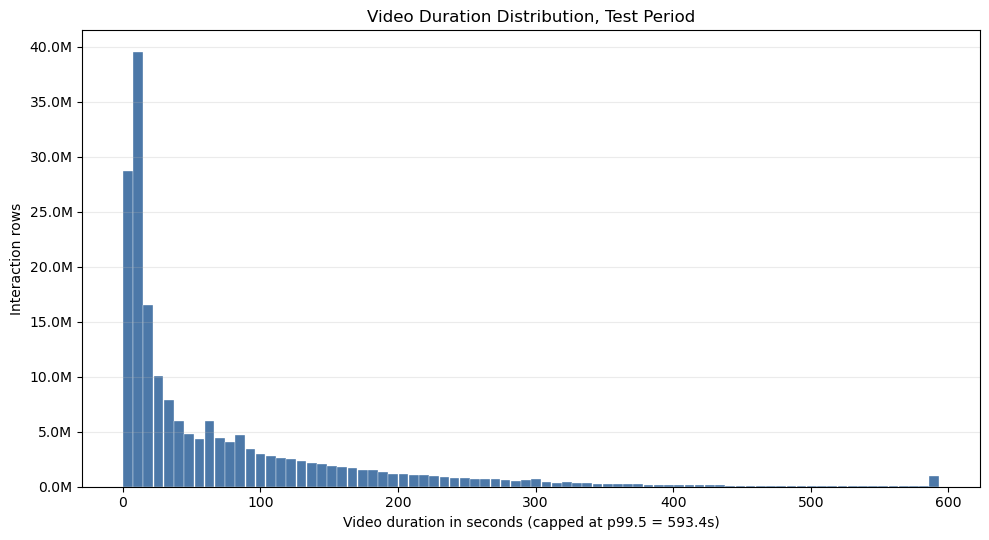

Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/figures/standard_plus_random_duration_histogram_p995.png


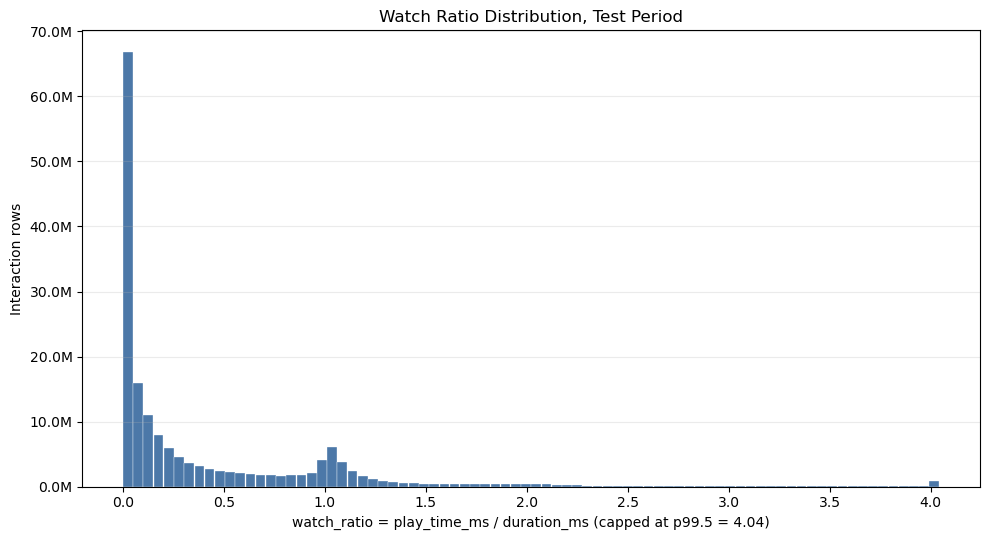

Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/figures/standard_plus_random_watch_ratio_histogram_p995.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)


def metric_stat(metric, stat):
    return float(
        behavior_summary
        .filter(pl.col('metric') == metric)
        .select(stat)
        .item()
    )


def exact_histogram(lf, value_col, cap, n_bins=80, filter_expr=None):
    width = cap / n_bins
    value = pl.col(value_col).cast(pl.Float64)
    raw_idx = (value / width).floor()
    bin_idx = (
        pl.when(raw_idx < 0).then(0)
        .when(raw_idx >= n_bins).then(n_bins - 1)
        .otherwise(raw_idx)
        .cast(pl.Int32)
        .alias('bin_idx')
    )

    base = lf
    if filter_expr is not None:
        base = base.filter(filter_expr)

    counts = (
        base
        .with_columns(bin_idx)
        .group_by('bin_idx')
        .agg(pl.len().alias('n_interactions'))
        .collect(engine='streaming')
    )
    all_bins = pl.DataFrame({'bin_idx': list(range(n_bins))}, schema={'bin_idx': pl.Int32})
    hist = (
        all_bins
        .join(counts, on='bin_idx', how='left')
        .with_columns(pl.col('n_interactions').fill_null(0).cast(pl.Int64))
        .with_columns([
            (pl.col('bin_idx') * width).alias('bin_left'),
            ((pl.col('bin_idx') + 1) * width).alias('bin_right'),
            ((pl.col('bin_idx') + 0.5) * width).alias('bin_mid'),
        ])
        .select(['bin_idx', 'bin_left', 'bin_right', 'bin_mid', 'n_interactions'])
    )
    return hist


def millions_formatter(x, _pos):
    return f'{x / 1_000_000:.1f}M'


def plot_histogram(hist, title, xlabel, output_path, cap_note):
    pdf = hist.to_pandas()
    width = float(pdf['bin_right'].iloc[0] - pdf['bin_left'].iloc[0])
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.bar(
        pdf['bin_mid'],
        pdf['n_interactions'],
        width=width * 0.95,
        color='#4C78A8',
        edgecolor='white',
        linewidth=0.25,
    )
    ax.set_title(title)
    ax.set_xlabel(f'{xlabel} ({cap_note})')
    ax.set_ylabel('Interaction rows')
    ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(output_path, dpi=180)
    plt.show()
    print(f'Saved: {output_path}')


duration_cap_s = metric_stat('duration_s', 'p995')
watch_ratio_cap = metric_stat('watch_ratio', 'p995')

# Include zero-duration rows in the duration histogram, but only non-null watch ratios in the watch-ratio histogram.
duration_hist = exact_histogram(
    behavior_lf,
    value_col='duration_s',
    cap=duration_cap_s,
    n_bins=80,
    filter_expr=pl.col('duration_s').is_not_null(),
)
watch_ratio_hist = exact_histogram(
    behavior_lf,
    value_col='watch_ratio',
    cap=watch_ratio_cap,
    n_bins=80,
    filter_expr=pl.col('watch_ratio').is_not_null(),
)

duration_hist_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_duration_histogram_p995.csv'
watch_ratio_hist_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_watch_ratio_histogram_p995.csv'
duration_hist.write_csv(duration_hist_path)
watch_ratio_hist.write_csv(watch_ratio_hist_path)
print(f'Saved: {duration_hist_path}')
print(f'Saved: {watch_ratio_hist_path}')

duration_fig_path = FIG_DIR / f'{ALL_INTERACTIONS_SCOPE}_duration_histogram_p995.png'
watch_ratio_fig_path = FIG_DIR / f'{ALL_INTERACTIONS_SCOPE}_watch_ratio_histogram_p995.png'

plot_histogram(
    duration_hist,
    title='Video Duration Distribution, Test Period',
    xlabel='Video duration in seconds',
    output_path=duration_fig_path,
    cap_note=f'capped at p99.5 = {duration_cap_s:.1f}s',
)
plot_histogram(
    watch_ratio_hist,
    title='Watch Ratio Distribution, Test Period',
    xlabel='watch_ratio = play_time_ms / duration_ms',
    output_path=watch_ratio_fig_path,
    cap_note=f'capped at p99.5 = {watch_ratio_cap:.2f}',
)

## Random Recommendation Summary

This section isolates random-intervention rows. In the local test-period files, the two standard logs have `is_rand = 0` for every row, while `log_random_4_22_to_5_08_27k.csv` has `is_rand = 1` for every row. Therefore, random rows are exactly the rows from the separate random log.

Random exposure results:

| Quantity | Result |
|---|---:|
| Random rows | 1,186,059 |
| Random rows as share of all `standard_plus_random` rows | 0.634% |
| User-timestamps with a random row | 1,186,049 |
| Share of all user-timestamps with a random row | 3.69% |
| Random rows in truly singleton timestamps | 35,639 |
| Share of random rows in truly singleton timestamps | 3.00% |
| Max random rows at one timestamp | 2 |

Almost all random rows are in `tab=1`: 1,178,025 rows, or 99.32% of random rows. The remaining random rows are in `tab=11` (0.57%), `tab=2` (0.064%), and `tab=14` (0.043%).

Random-only behavior differs from the full log:

| Metric | Random median | Random mean | Random p90 | Random p99.5 |
|---|---:|---:|---:|---:|
| Video duration | 76.8s | 104.4s | 233.0s | 610.2s |
| Watch/play time | 2.09s | 6.94s | 13.0s | 124.4s |
| Watch ratio | 0.0348 | 0.141 | 0.356 | 1.709 |

Interpretation: random videos are much less watched than the full recommendation log, with a much lower median watch ratio. Crucially, only 3.00% of random rows are truly singleton timestamp moments after accounting for the standard rows at the same `(user_id, time_ms)`. This is the strongest evidence that the random validation sample is mostly not a clean one-video-at-a-time sequential setting.

Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_random_recommendation_summary.csv


n_all_recommendation_rows,n_random_recommendation_rows,fraction_random_over_rows,pct_random_over_rows,n_all_user_timestamps,n_user_timestamps_with_random,fraction_random_over_timestamps,pct_random_over_timestamps,n_random_rows_in_singleton_timestamp,fraction_random_rows_in_singleton_timestamp,pct_random_rows_in_singleton_timestamp,n_random_timestamps_singleton_all_rows,fraction_random_timestamps_that_are_singleton,pct_random_timestamps_that_are_singleton,max_random_rows_at_one_timestamp
i64,i64,f64,f64,i64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64
187167868,1186059,0.006337,0.633687,32111619,1186049,0.036935,3.69352,35639,0.030048,3.004825,35639,0.030049,3.004851,2


Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_random_tab_distribution.csv


tab,n_random_rows,share_random_rows,pct_random_rows
u8,u32,f64,f64
1,1178025,0.993226,99.3226
2,764,0.000644,0.0644
11,6755,0.005695,0.5695
14,515,0.000434,0.0434


Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_random_duration_watch_ratio_summary.csv


metric,label,n_nonnull,n_null,mean,std,min,p01,p05,p10,p25,p50,p75,p90,p95,p99,p995,p999,max
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""duration_ms""","""video duration (ms)""",1186059,0,104438.833147,104987.255132,0.0,0.0,8400.0,12333.0,28366.0,76833.0,144233.0,232966.0,298450.0,507666.0,610200.0,775066.0,1.17772e6
"""duration_s""","""video duration (seconds)""",1186059,0,104.438833,104.987255,0.0,0.0,8.4,12.333,28.366,76.833,144.233,232.966,298.45,507.666,610.2,775.066,1177.72
"""play_time_ms""","""watch/play time (ms)""",1186059,0,6935.5113,18791.557466,0.0,221.0,862.0,1019.0,1333.0,2091.0,4593.0,13003.0,27887.0,91334.0,124447.0,220201.0,1.023809e6
"""play_time_s""","""watch/play time (seconds)""",1186059,0,6.935511,18.791557,0.0,0.221,0.862,1.019,1.333,2.091,4.593,13.003,27.887,91.334,124.447,220.201,1023.809
"""watch_ratio""","""watch ratio = play_time_ms / duration_ms""",1149139,36920,0.141315,0.393593,0.0,0.001483,0.004672,0.006845,0.013576,0.034798,0.111178,0.355714,0.776667,1.23615,1.708506,3.332812,103.129252


Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_random_duration_histogram_p995.csv
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_random_watch_ratio_histogram_p995.csv


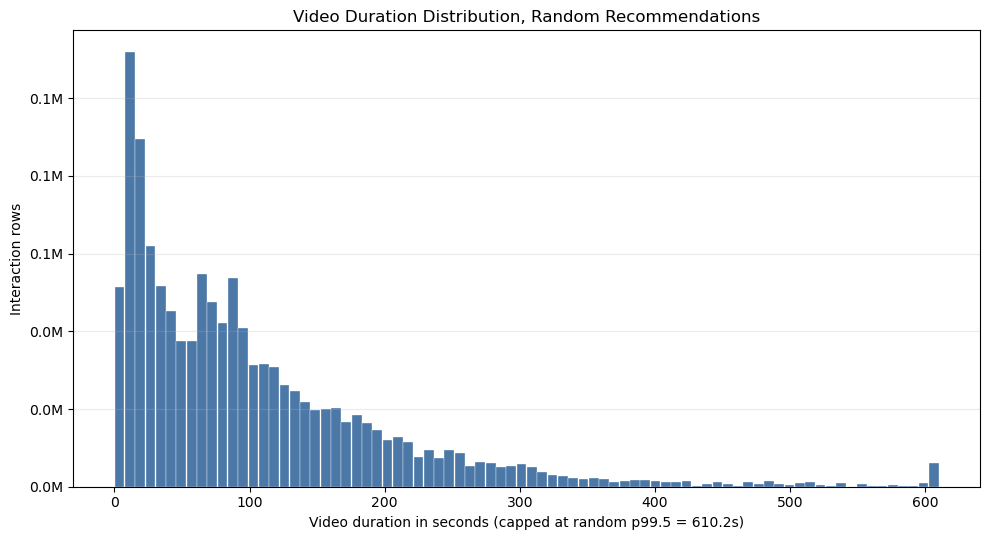

Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/figures/standard_plus_random_random_duration_histogram_p995.png


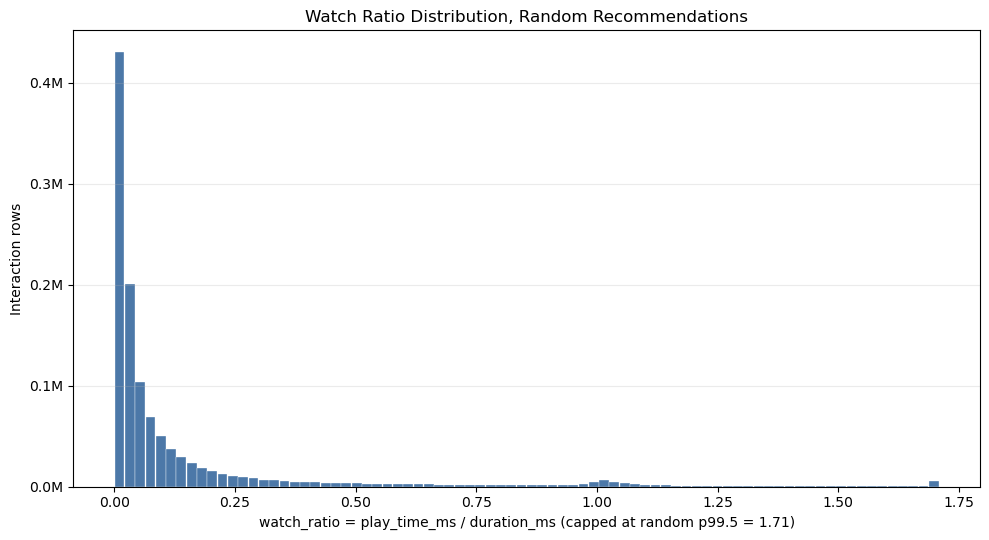

Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/figures/standard_plus_random_random_watch_ratio_histogram_p995.png


In [6]:
random_lf = scan_csv_cols(ALL_INTERACTION_FILES, ['user_id', 'time_ms', 'is_rand', 'tab', 'duration_ms', 'play_time_ms'])

row_summary = random_lf.select([
    pl.len().alias('n_all_recommendation_rows'),
    (pl.col('is_rand') == 1).sum().alias('n_random_recommendation_rows'),
]).collect(engine='streaming')

random_timestamp_summary = (
    random_lf
    .group_by(['user_id', 'time_ms'])
    .agg([
        pl.len().alias('n_rows_at_timestamp'),
        (pl.col('is_rand') == 1).sum().alias('n_random_rows_at_timestamp'),
        (pl.col('is_rand') == 1).any().alias('has_random_row'),
    ])
    .select([
        pl.len().alias('n_all_user_timestamps'),
        pl.col('has_random_row').sum().alias('n_user_timestamps_with_random'),
        pl.col('n_random_rows_at_timestamp').sum().alias('n_random_rows_from_timestamp_table'),
        pl.when(pl.col('n_rows_at_timestamp') == 1)
        .then(pl.col('n_random_rows_at_timestamp'))
        .otherwise(0)
        .sum()
        .alias('n_random_rows_in_singleton_timestamp'),
        ((pl.col('has_random_row')) & (pl.col('n_rows_at_timestamp') == 1))
        .sum()
        .alias('n_random_timestamps_singleton_all_rows'),
        pl.col('n_random_rows_at_timestamp').max().alias('max_random_rows_at_one_timestamp'),
    ])
    .collect(engine='streaming')
)

n_all_rows = int(row_summary['n_all_recommendation_rows'][0])
n_random_rows = int(row_summary['n_random_recommendation_rows'][0])
n_all_timestamps = int(random_timestamp_summary['n_all_user_timestamps'][0])
n_timestamps_with_random = int(random_timestamp_summary['n_user_timestamps_with_random'][0])
n_random_rows_in_singleton_timestamp = int(random_timestamp_summary['n_random_rows_in_singleton_timestamp'][0])
n_random_timestamps_singleton_all_rows = int(random_timestamp_summary['n_random_timestamps_singleton_all_rows'][0])

random_recommendation_summary = pl.DataFrame({
    'n_all_recommendation_rows': [n_all_rows],
    'n_random_recommendation_rows': [n_random_rows],
    'fraction_random_over_rows': [n_random_rows / n_all_rows],
    'pct_random_over_rows': [100 * n_random_rows / n_all_rows],
    'n_all_user_timestamps': [n_all_timestamps],
    'n_user_timestamps_with_random': [n_timestamps_with_random],
    'fraction_random_over_timestamps': [n_timestamps_with_random / n_all_timestamps],
    'pct_random_over_timestamps': [100 * n_timestamps_with_random / n_all_timestamps],
    'n_random_rows_in_singleton_timestamp': [n_random_rows_in_singleton_timestamp],
    'fraction_random_rows_in_singleton_timestamp': [n_random_rows_in_singleton_timestamp / n_random_rows],
    'pct_random_rows_in_singleton_timestamp': [100 * n_random_rows_in_singleton_timestamp / n_random_rows],
    'n_random_timestamps_singleton_all_rows': [n_random_timestamps_singleton_all_rows],
    'fraction_random_timestamps_that_are_singleton': [n_random_timestamps_singleton_all_rows / n_timestamps_with_random],
    'pct_random_timestamps_that_are_singleton': [100 * n_random_timestamps_singleton_all_rows / n_timestamps_with_random],
    'max_random_rows_at_one_timestamp': [int(random_timestamp_summary['max_random_rows_at_one_timestamp'][0])],
})

random_summary_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_random_recommendation_summary.csv'
random_recommendation_summary.write_csv(random_summary_path)
print(f'Saved: {random_summary_path}')
display(random_recommendation_summary)

random_tab_distribution = (
    random_lf
    .filter(pl.col('is_rand') == 1)
    .group_by('tab')
    .agg(pl.len().alias('n_random_rows'))
    .sort('tab')
    .collect(engine='streaming')
)
random_tab_distribution = random_tab_distribution.with_columns([
    (pl.col('n_random_rows') / n_random_rows).alias('share_random_rows'),
    (100.0 * pl.col('n_random_rows') / n_random_rows).round(4).alias('pct_random_rows'),
])
random_tab_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_random_tab_distribution.csv'
random_tab_distribution.write_csv(random_tab_path)
print(f'Saved: {random_tab_path}')
display(random_tab_distribution)

random_behavior_lf = (
    random_lf
    .filter(pl.col('is_rand') == 1)
    .with_columns([
        (pl.col('duration_ms') / 1000.0).alias('duration_s'),
        (pl.col('play_time_ms') / 1000.0).alias('play_time_s'),
        pl.when(pl.col('duration_ms') > 0)
        .then(pl.col('play_time_ms') / pl.col('duration_ms'))
        .otherwise(None)
        .alias('watch_ratio'),
    ])
)

random_summary_exprs = []
for col, _label in METRIC_SPECS:
    random_summary_exprs.extend([
        pl.col(col).is_not_null().sum().alias(f'{col}__n_nonnull'),
        pl.col(col).is_null().sum().alias(f'{col}__n_null'),
        pl.col(col).mean().alias(f'{col}__mean'),
        pl.col(col).std().alias(f'{col}__std'),
        pl.col(col).min().alias(f'{col}__min'),
        pl.col(col).max().alias(f'{col}__max'),
    ])
    for q_name, q_value in QUANTILES:
        random_summary_exprs.append(pl.col(col).quantile(q_value).alias(f'{col}__{q_name}'))

random_wide_summary = random_behavior_lf.select(random_summary_exprs).collect(engine='streaming')
random_summary_rows = []
for col, label in METRIC_SPECS:
    row = {'metric': col, 'label': label}
    for stat in ['n_nonnull', 'n_null', 'mean', 'std', 'min', *[name for name, _ in QUANTILES], 'max']:
        row[stat] = random_wide_summary[f'{col}__{stat}'][0]
    random_summary_rows.append(row)

random_behavior_summary = pl.DataFrame(random_summary_rows)
random_behavior_summary_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_random_duration_watch_ratio_summary.csv'
random_behavior_summary.write_csv(random_behavior_summary_path)
print(f'Saved: {random_behavior_summary_path}')
display(random_behavior_summary)

random_duration_cap_s = float(
    random_behavior_summary.filter(pl.col('metric') == 'duration_s').select('p995').item()
)
random_watch_ratio_cap = float(
    random_behavior_summary.filter(pl.col('metric') == 'watch_ratio').select('p995').item()
)

random_duration_hist = exact_histogram(
    random_behavior_lf,
    value_col='duration_s',
    cap=random_duration_cap_s,
    n_bins=80,
    filter_expr=pl.col('duration_s').is_not_null(),
)
random_watch_ratio_hist = exact_histogram(
    random_behavior_lf,
    value_col='watch_ratio',
    cap=random_watch_ratio_cap,
    n_bins=80,
    filter_expr=pl.col('watch_ratio').is_not_null(),
)

random_duration_hist_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_random_duration_histogram_p995.csv'
random_watch_ratio_hist_path = OUT_DIR / f'{ALL_INTERACTIONS_SCOPE}_random_watch_ratio_histogram_p995.csv'
random_duration_hist.write_csv(random_duration_hist_path)
random_watch_ratio_hist.write_csv(random_watch_ratio_hist_path)
print(f'Saved: {random_duration_hist_path}')
print(f'Saved: {random_watch_ratio_hist_path}')

random_duration_fig_path = FIG_DIR / f'{ALL_INTERACTIONS_SCOPE}_random_duration_histogram_p995.png'
random_watch_ratio_fig_path = FIG_DIR / f'{ALL_INTERACTIONS_SCOPE}_random_watch_ratio_histogram_p995.png'

plot_histogram(
    random_duration_hist,
    title='Video Duration Distribution, Random Recommendations',
    xlabel='Video duration in seconds',
    output_path=random_duration_fig_path,
    cap_note=f'capped at random p99.5 = {random_duration_cap_s:.1f}s',
)
plot_histogram(
    random_watch_ratio_hist,
    title='Watch Ratio Distribution, Random Recommendations',
    xlabel='watch_ratio = play_time_ms / duration_ms',
    output_path=random_watch_ratio_fig_path,
    cap_note=f'capped at random p99.5 = {random_watch_ratio_cap:.2f}',
)

## Policy Distribution by `tab`

The `tab` column is the released policy/scenario identifier. The official docs do not provide a public mapping from tab values to human-readable UI names, so this notebook treats `tab` as an anonymized scenario ID.

In `standard_plus_random`, the policy distribution is highly concentrated:

| Tab | Rows | Share |
|---:|---:|---:|
| 1 | 126,841,985 | 67.77% |
| 0 | 36,032,462 | 19.25% |
| 4 | 13,944,491 | 7.45% |
| 2 | 5,425,413 | 2.90% |
| 6 | 3,467,419 | 1.85% |
| 3 | 444,366 | 0.24% |
| 10 | 13,449 | 0.007% |

For the standard-only logs, the shares are nearly the same: `tab=1` is 67.57%, `tab=0` is 19.37%, and `tab=4` is 7.50%. The rare singleton-looking `tab=10` remains only 0.007% of standard rows and has no random rows.

In [7]:
def compute_policy_distribution(paths):
    counts = (
        scan_csv_cols(paths, ['tab'])
        .group_by('tab')
        .agg(pl.len().alias('n_interactions'))
        .sort('tab')
        .collect(engine='streaming')
    )

    all_tabs = pl.DataFrame({'tab': list(range(15))}, schema={'tab': pl.UInt8})
    counts = all_tabs.join(counts, on='tab', how='left').with_columns(
        pl.col('n_interactions').fill_null(0).cast(pl.Int64)
    )
    total = int(counts['n_interactions'].sum())
    return counts.with_columns([
        (pl.col('n_interactions') / total).alias('share_interactions'),
        (100 * pl.col('n_interactions') / total).round(5).alias('pct_interactions'),
    ])


policy_tables = {}
for scope_name, paths in SCOPES.items():
    table = compute_policy_distribution(paths)
    policy_tables[scope_name] = table
    output_path = OUT_DIR / f'{scope_name}_policy_distribution_by_tab.csv'
    table.write_csv(output_path)
    print(f'\n=== {scope_name} ===')
    print(f'Saved: {output_path}')
    display(table)


=== standard_only ===
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_only_policy_distribution_by_tab.csv


tab,n_interactions,share_interactions,pct_interactions
u8,i64,f64,f64
0,36032462,0.193742,19.37419
1,125663960,0.675679,67.56788
2,5424649,0.029168,2.91676
3,444366,0.002389,0.23893
4,13944491,0.074978,7.49777
5,254213,0.001367,0.13669
6,3467419,0.018644,1.86439
7,57622,0.00031,0.03098
8,262721,0.001413,0.14126



=== standard_plus_random ===
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_policy_distribution_by_tab.csv


tab,n_interactions,share_interactions,pct_interactions
u8,i64,f64,f64
0,36032462,0.192514,19.25141
1,126841985,0.677691,67.7691
2,5425413,0.028987,2.89869
3,444366,0.002374,0.23742
4,13944491,0.074503,7.45026
5,254213,0.001358,0.13582
6,3467419,0.018526,1.85257
7,57622,0.000308,0.03079
8,262721,0.001404,0.14037


## Number of Videos Recorded at Each User Timestamp

A timestamp moment is defined as `(user_id, time_ms)`. For each moment, this section counts how many video rows are recorded at that exact user timestamp.

Main `standard_plus_random` result:

| Statistic | Value |
|---|---:|
| Interaction rows | 187,167,868 |
| User-timestamp moments | 32,111,619 |
| Mean videos per timestamp | 5.83 |
| Median videos per timestamp | 6 |
| p75 / p90 / p95 / p99 | 7 / 8 / 11 / 12 |
| Max videos at one timestamp | 60 |
| Singleton timestamp moments | 2,347,975, or 7.31% |
| Interaction rows in singleton moments | 1.25% |

The distribution is dominated by six-video moments: 13,665,254 user-timestamps, or 42.56% of moments, have exactly 6 videos and account for 43.81% of interaction rows. Seven-video moments add another 13.17% of moments and 15.82% of rows.

Interpretation: the test-period data is mostly slate-like or batched at the timestamp level. Treating every row as an independent sequential one-video exposure would be a strong approximation.

In [8]:
def compute_timestamp_distribution(paths):
    per_timestamp = (
        scan_csv_cols(paths, ['user_id', 'time_ms'])
        .group_by(['user_id', 'time_ms'])
        .len(name='n_videos_at_timestamp')
    )

    dist = (
        per_timestamp
        .group_by('n_videos_at_timestamp')
        .agg(pl.len().alias('n_user_timestamps'))
        .sort('n_videos_at_timestamp')
        .collect(engine='streaming')
    )
    dist = add_share_columns(dist)

    values = dist['n_videos_at_timestamp'].to_list()
    weights = dist['n_user_timestamps'].to_list()
    total_timestamps = int(sum(weights))
    total_rows = int(sum(value * weight for value, weight in zip(values, weights)))
    singleton_timestamps = int(
        dist.filter(pl.col('n_videos_at_timestamp') == 1)['n_user_timestamps'].sum()
    )

    summary = pl.DataFrame({
        'n_interaction_rows': [total_rows],
        'n_user_timestamps': [total_timestamps],
        'singleton_user_timestamps': [singleton_timestamps],
        'singleton_share_of_user_timestamps': [singleton_timestamps / total_timestamps],
        'singleton_share_of_interaction_rows': [singleton_timestamps / total_rows],
        'mean_videos_per_timestamp': [total_rows / total_timestamps],
        'median_videos_per_timestamp': [nearest_rank_quantile_from_distribution(values, weights, 0.50)],
        'p75_videos_per_timestamp': [nearest_rank_quantile_from_distribution(values, weights, 0.75)],
        'p90_videos_per_timestamp': [nearest_rank_quantile_from_distribution(values, weights, 0.90)],
        'p95_videos_per_timestamp': [nearest_rank_quantile_from_distribution(values, weights, 0.95)],
        'p99_videos_per_timestamp': [nearest_rank_quantile_from_distribution(values, weights, 0.99)],
        'max_videos_per_timestamp': [max(values)],
    })

    return summary, dist


timestamp_summaries = {}
timestamp_distributions = {}

for scope_name, paths in SCOPES.items():
    summary, dist = compute_timestamp_distribution(paths)
    timestamp_summaries[scope_name] = summary
    timestamp_distributions[scope_name] = dist

    summary_path = OUT_DIR / f'{scope_name}_timestamp_count_summary.csv'
    dist_path = OUT_DIR / f'{scope_name}_timestamp_count_distribution.csv'
    summary.write_csv(summary_path)
    dist.write_csv(dist_path)

    print(f'\n=== {scope_name} ===')
    print(f'Saved: {summary_path}')
    print(f'Saved: {dist_path}')
    display(summary)
    display(dist)


=== standard_only ===
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_only_timestamp_count_summary.csv
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_only_timestamp_count_distribution.csv


n_interaction_rows,n_user_timestamps,singleton_user_timestamps,singleton_share_of_user_timestamps,singleton_share_of_interaction_rows,mean_videos_per_timestamp,median_videos_per_timestamp,p75_videos_per_timestamp,p90_videos_per_timestamp,p95_videos_per_timestamp,p99_videos_per_timestamp,max_videos_per_timestamp
i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64
185981809,32075980,2331703,0.072693,0.012537,5.798165,6,7,8,11,12,60


n_videos_at_timestamp,n_user_timestamps,share_user_timestamps,share_interaction_rows,pct_user_timestamps,pct_interaction_rows
u32,u32,f64,f64,f64,f64
1,2331703,0.072693,0.012537,7.2693,1.2537
2,1656371,0.051639,0.017812,5.1639,1.7812
3,1092898,0.034072,0.017629,3.4072,1.7629
4,1509070,0.047047,0.032456,4.7047,3.2456
5,3370966,0.105093,0.090626,10.5093,9.0626
6,13253762,0.413199,0.427583,41.3199,42.7583
7,4101360,0.127864,0.154367,12.7864,15.4367
8,1795286,0.05597,0.077224,5.597,7.7224
9,560811,0.017484,0.027139,1.7484,2.7139



=== standard_plus_random ===
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_timestamp_count_summary.csv
Saved: /Users/haozhangao/Desktop/RecSys Research/python_code_KuaiRand/outputs/standard_plus_random_timestamp_count_distribution.csv


n_interaction_rows,n_user_timestamps,singleton_user_timestamps,singleton_share_of_user_timestamps,singleton_share_of_interaction_rows,mean_videos_per_timestamp,median_videos_per_timestamp,p75_videos_per_timestamp,p90_videos_per_timestamp,p95_videos_per_timestamp,p99_videos_per_timestamp,max_videos_per_timestamp
i64,i64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64
187167868,32111619,2347975,0.073119,0.012545,5.828665,6,7,8,11,12,60


n_videos_at_timestamp,n_user_timestamps,share_user_timestamps,share_interaction_rows,pct_user_timestamps,pct_interaction_rows
u32,u32,f64,f64,f64,f64
1,2347975,0.073119,0.012545,7.3119,1.2545
2,1654736,0.051531,0.017682,5.1531,1.7682
3,1084234,0.033765,0.017379,3.3765,1.7379
4,1447793,0.045086,0.030941,4.5086,3.0941
5,2824868,0.08797,0.075463,8.797,7.5463
6,13665254,0.425555,0.438064,42.5555,43.8064
7,4230139,0.131732,0.158205,13.1732,15.8205
8,1867532,0.058158,0.079823,5.8158,7.9823
9,580092,0.018065,0.027894,1.8065,2.7894


## Quick Takeaway Cell

The final cell prints the key singleton-exposure takeaway from the executed summary tables.

Bottom line for the validation design:

- The overall test-period log is mostly multi-video timestamp moments, with median 6 videos per `(user_id, time_ms)`.
- Only 7.31% of user-timestamps are singleton moments in `standard_plus_random`.
- Only 1.25% of all interaction rows belong to singleton moments.
- Only 35,639 random rows, or 3.00% of random rows, are in truly singleton timestamps.

Before cleaning features for ML inference, the next important diagnostics should be: join coverage for user/video/category features, a serving-time leakage audit, and covariate-shift checks comparing random rows against standard rows by `tab`, duration, hour, user metadata, and video metadata.

In [9]:
for scope_name, summary in timestamp_summaries.items():
    row = summary.row(0, named=True)
    print(
        f"{scope_name}: "
        f"{row['singleton_user_timestamps']:,} singleton user-timestamps "
        f"out of {row['n_user_timestamps']:,} "
        f"({100 * row['singleton_share_of_user_timestamps']:.2f}% of moments; "
        f"{100 * row['singleton_share_of_interaction_rows']:.2f}% of rows). "
        f"Median videos/timestamp = {row['median_videos_per_timestamp']}."
    )

standard_only: 2,331,703 singleton user-timestamps out of 32,075,980 (7.27% of moments; 1.25% of rows). Median videos/timestamp = 6.
standard_plus_random: 2,347,975 singleton user-timestamps out of 32,111,619 (7.31% of moments; 1.25% of rows). Median videos/timestamp = 6.
